In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,roc_auc_score, roc_curve, auc)
import warnings
warnings.filterwarnings("ignore")

def quantDDA(df):
  dataframe = df.describe()

  # finding number of missing entries
  null_entries = df.isna().sum()
  null_entries = null_entries[dataframe.columns].to_frame().T
  null_entries.index = ["missing_entries"]

  # finding number of observations
  observations = (dataframe.loc["count"] + null_entries.iloc[0]).to_frame().T
  observations.index = ["num_of_observations"]

  # finding number of unique entries
  unique_entries = df.nunique()
  unique_entries = unique_entries[dataframe.columns].to_frame().T
  unique_entries.index = ["unique_entries"]

  # finding number of outliers
  z_scores = df[dataframe.columns]
  z_scores = pd.DataFrame(np.abs(stats.zscore(z_scores)), columns=dataframe.columns)
  threshold = 3
  outliers = (z_scores > threshold).sum().to_frame().T
  outliers.index = ["num_of_outliers"]

  # finding number of extremes (top/bottom 1%)
  top_one_percent_threshold = df.quantile(0.99, numeric_only=True)
  top_one_percent = (df[dataframe.columns] > top_one_percent_threshold).sum().to_frame().T
  top_one_percent.index = ["values_in_top_one_percent"]

  bottom_one_percent_threshold = df.quantile(0.01, numeric_only=True)
  bottom_one_percent = (df[dataframe.columns] < bottom_one_percent_threshold).sum().to_frame().T
  bottom_one_percent.index = ["values_in_bottom_one_percent"]

  # finding mode
  mode = df.mode()
  mode = mode[dataframe.columns].iloc[0].to_frame().T
  mode.index = ["mode"]

  # finding skewness
  skewness = df[dataframe.columns].skew().to_frame().T
  skewness.index = ["skewness"]

  # finding kurtosis
  kurtosis = df[dataframe.columns].kurtosis().to_frame().T
  kurtosis.index = ["kurtosis"]

  # concatenating all dataframes into one
  dataframe = pd.concat([dataframe, null_entries, observations, unique_entries, outliers, top_one_percent, bottom_one_percent, mode, skewness, kurtosis])
  return dataframe



In [24]:
def vizDDA(df):
  cols = df.columns
  n = len(cols)
  fig, axes = plt.subplots(n, n, figsize=(4*n, 4*n))

  high_card = {c for c in cols if df[c].dtype == "object" and df[c].nunique() > 8}

  for i, col1 in enumerate(cols):
    for j, col2 in enumerate(cols):
      ax = axes[i, j]

      # Skip the bottom triangle
      if j < i:
        ax.set_visible(False)
        continue

      if i == j:
        ax.set_xlabel(col2)
      else:
        ax.set_xticklabels([])
        ax.set_xlabel("")

      if j == i:
        ax.set_ylabel(col1)
      else:
        ax.set_yticklabels([])
        ax.set_ylabel("")

      if col1 in high_card or col2 in high_card:
        ax.text(0.5, 0.5, f"Too many\ncategories", ha="center", va="center", transform=ax.transAxes, fontsize=9, color="gray")
        ax.set_xticks([])
        ax.set_yticks([])
        continue


      if i == j:
        if pd.api.types.is_numeric_dtype(df[col1]):
          sns.histplot(df[col1], ax=ax)
        elif df[col1].dtype == "object":
          sns.countplot(x=df[col1], ax=ax)
      else:
        if pd.api.types.is_numeric_dtype(df[col1]) and pd.api.types.is_numeric_dtype(df[col2]):
          sns.scatterplot(x=df[col2], y=df[col1], ax=ax)
        elif pd.api.types.is_numeric_dtype(df[col1]) and df[col2].dtype == "object":
          sns.boxplot(x=df[col2], y=df[col1], ax=ax)
        elif pd.api.types.is_datetime64_any_dtype(df[col2]) and pd.api.types.is_numeric_dtype(df[col1]):
          sns.lineplot(x=df[col2], y=df[col1], ax=ax)
        else:
          ax.set_visible(False)

  fig.suptitle("Grid of plots")
  plt.tight_layout()
  plt.show()

  # Heatmap of missing values
  plt.figure(figsize=(10, 6))
  sns.heatmap(df.isnull(), cbar=False)
  plt.title("Heatmap of Missing Values")
  plt.show()

In [25]:
# initial dataset
chess_df = pd.read_csv(
    "chess-data.csv",
    usecols=["Event", "Result", "WhiteElo", "BlackElo", "TimeControl", "WhiteTitle", "BlackTitle", "ECO", "Opening", "WhiteRatingDiff", "BlackRatingDiff"],
    low_memory=False
);

# cleaning dataset

chess_df["WhiteElo"] = pd.to_numeric(chess_df["WhiteElo"], errors="coerce")
chess_df["BlackElo"] = pd.to_numeric(chess_df["BlackElo"], errors="coerce")

#checking percentage of missing values
print(chess_df.isna().mean()*100)

#removing blank columns (WhiteTitle and BlackTitle)
chess_df = chess_df.drop(['WhiteTitle', 'BlackTitle'], axis = 1)

#removing duplicate rows
num_duplicates = chess_df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

chess_df = chess_df.drop_duplicates()

# removing missing values
chess_df = chess_df.dropna(subset=['WhiteElo','BlackElo','WhiteRatingDiff','BlackRatingDiff'])

# adding Winner column
chess_df['Winner'] = chess_df['Result'].map({
    '1-0' : 'White',
    '0-1': 'Black',
    '1/2-1/2':'Draw'
})

# adding EncodedWinner column
chess_df['EncodedWinner'] = chess_df['Winner'].map({
    'White': 0,
    'Black': 1,
    'Draw': 2
})

chess_df.head(10)

Event               0.000000
Result              0.000000
WhiteElo            0.000041
BlackElo            0.000204
WhiteRatingDiff     0.081455
BlackRatingDiff     0.081455
WhiteTitle         99.472131
ECO                 0.000000
Opening             0.000000
TimeControl         0.000000
BlackTitle         99.467239
dtype: float64
Number of duplicate rows: 871


,Event,Result,WhiteElo,BlackElo,WhiteRatingDiff,BlackRatingDiff,ECO,Opening,TimeControl,Winner,EncodedWinner
0,Rated Blitz game,0-1,1623.0,1622.0,-10.0,11.0,B12,"Caro-Kann Defense: Advance Variation, Short Va...",180+0,Black,1
1,Rated Bullet tournament https://lichess.org/to...,0-1,1398.0,2134.0,0.0,0.0,C02,French Defense: Advance Variation,60+0,Black,1
2,Rated Blitz game,1-0,1827.0,1880.0,12.0,-13.0,C44,Scotch Game: Scotch Gambit,180+0,White,0
3,Rated Classical game,1-0,1839.0,1811.0,12.0,-10.0,B01,Scandinavian Defense,900+15,White,0
4,Rated Bullet game,1-0,1918.0,1866.0,10.0,-9.0,B32,Sicilian Defense: Open #3,30+0,White,0
5,Rated Bullet tournament https://lichess.org/to...,1-0,2350.0,1698.0,1.0,-1.0,D00,Queen's Pawn Game #2,60+0,White,0
6,Rated Classical game,0-1,1744.0,1885.0,-7.0,7.0,B06,Robatsch (Modern) Defense,600+0,Black,1
7,Rated Blitz game,1-0,1816.0,1619.0,6.0,-6.0,A40,Horwitz Defense,300+3,White,0
8,Rated Bullet game,0-1,1515.0,1905.0,-2.0,3.0,A00,Van Geet Opening,60+0,Black,1
9,Rated Classical game,0-1,1489.0,1694.0,-8.0,9.0,B09,Pirc Defense: Austrian Attack,300+8,Black,1


In [26]:
quantDDA(chess_df)

,WhiteElo,BlackElo,WhiteRatingDiff,BlackRatingDiff,EncodedWinner
count,2.450182e+06,2.450182e+06,2.450182e+06,2.450182e+06,2.450182e+06
mean,1.737377e+03,1.734983e+03,6.208845e-01,-2.796727e-01,5.387400e-01
std,2.817137e+02,2.832005e+02,2.471483e+01,2.450910e+01,5.673526e-01
min,7.310000e+02,7.360000e+02,-6.000000e+02,-6.150000e+02,0.000000e+00
25%,1.543000e+03,1.540000e+03,-9.000000e+00,-1.000000e+01,0.000000e+00
50%,1.734000e+03,1.732000e+03,1.000000e+00,-1.000000e+00,1.000000e+00
75%,1.922000e+03,1.921000e+03,1.000000e+01,9.000000e+00,1.000000e+00
max,2.993000e+03,3.102000e+03,6.820000e+02,6.820000e+02,2.000000e+00
missing_entries,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
num_of_observations,2.450182e+06,2.450182e+06,2.450182e+06,2.450182e+06,2.450182e+06


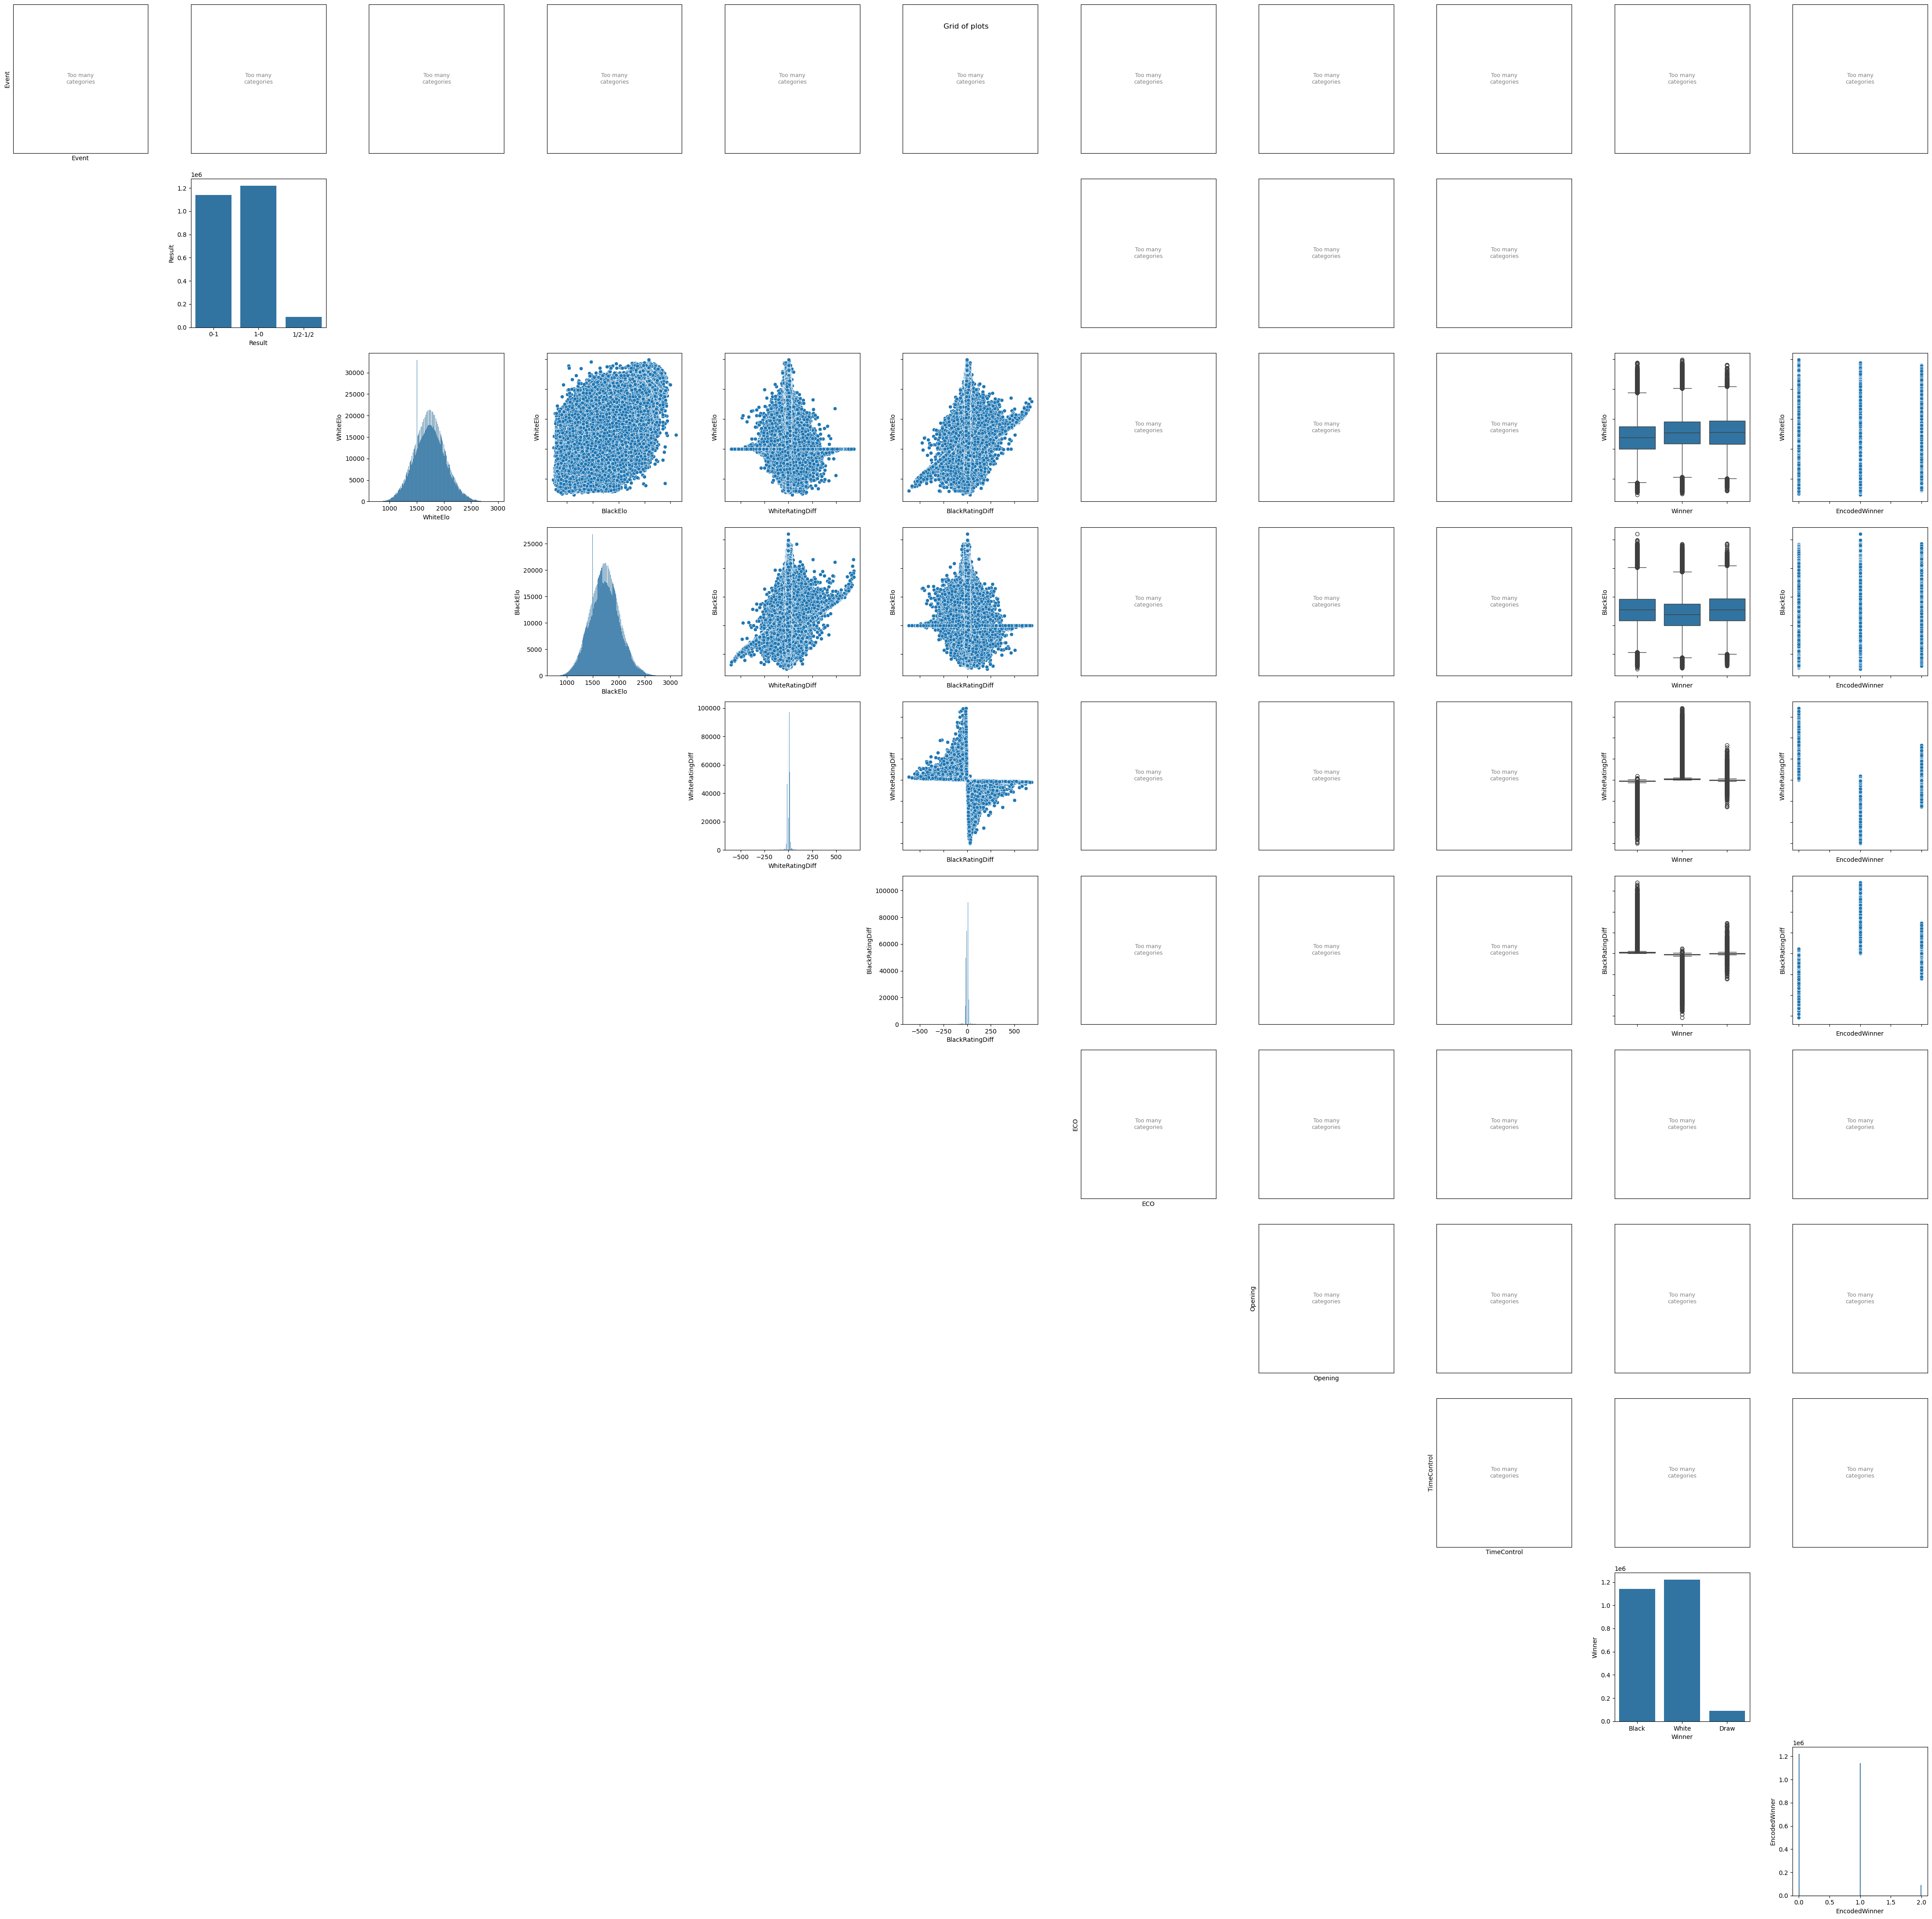

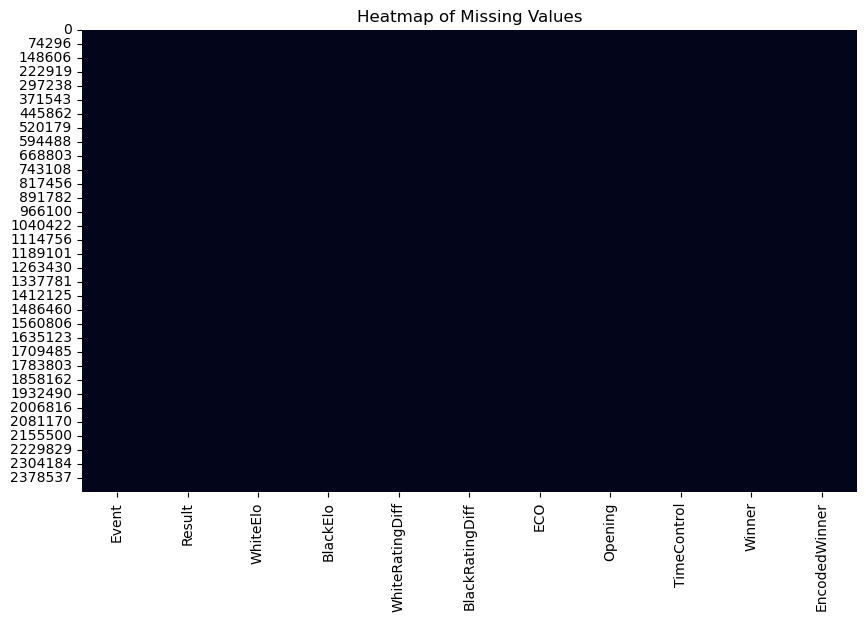

In [27]:
vizDDA(chess_df)

## EDA and Baseline Model
Summary statistics and uni/bivariate visualizations can be found using quantDDA and vizDDA.

Below shows a bivariate visualization between the 'WhiteElo' and 'Winner' columns. The same applies for 'BlackElo' and 'Winner' columns.

The boxplot shows that players with a rating advantage are more likely to win. Also, when there is little to no rating difference, there is a higher chance of the game ending in a draw.

A correlation matrix was computed to analyze the relationship between WhiteElo and BlackElo. The heatmap visualization shows the strength and direction of correlation between these rating difference variables.

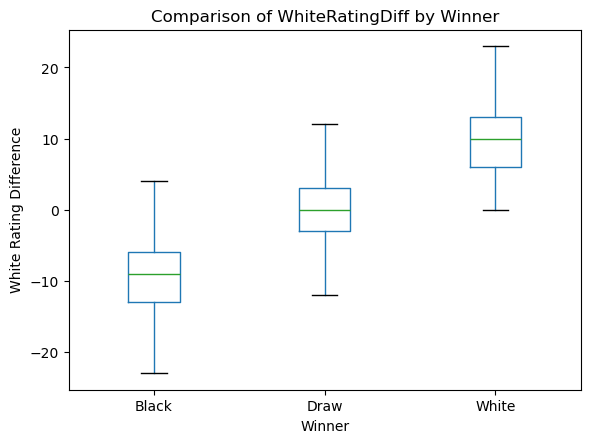

In [28]:
# boxplot of WhiteRatingDiff and Winner
chess_df.boxplot(column='WhiteRatingDiff', by='Winner', showfliers=False, grid=False)
plt.title('Comparison of WhiteRatingDiff by Winner')
plt.suptitle('')
plt.xlabel('Winner')
plt.ylabel('White Rating Difference')
plt.show()

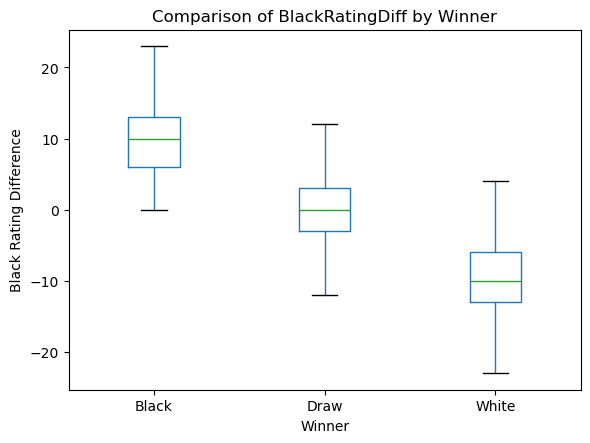

In [29]:
# boxplot of BlackRatingDiff and Winner
chess_df.boxplot(column='BlackRatingDiff', by='Winner', showfliers=False, grid=False)
plt.title('Comparison of BlackRatingDiff by Winner')
plt.suptitle('')
plt.xlabel('Winner')
plt.ylabel('Black Rating Difference')
plt.show()

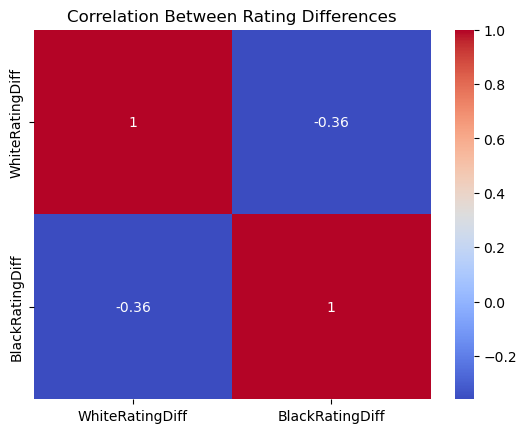

In [30]:
# Correlation matrix for numeric variables
corr = chess_df[['WhiteRatingDiff', 'BlackRatingDiff']].corr()

# Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Between Rating Differences")
plt.show()

In [31]:
# linear regression

from sklearn.linear_model import LinearRegression

chess_df['WinnerNumeric'] = chess_df['Winner'].map({
    'White': 1,
    'Black': 0,
    'Draw': 0.5
})

X = chess_df[['WhiteRatingDiff']]
y = chess_df['WinnerNumeric']

model = LinearRegression()
model.fit(X, y)

print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)
print("R^2:", model.score(X, y))

Coefficient: [0.01006814]
Intercept: 0.5100511044626515
R^2: 0.2573887314150618


## Research Questions

Given the previous observations, we came up with the following supervised and unsupervised research questions respectively:

1. Can a model be trained to accurately predict the result of an online chess game based on factors like elo and rating?

2. Can we categorize chess games into different difficulty levels based on time control, rating difference, and opening type?

In [ ]:
# feature engineering

chess_df['EloDiff'] = chess_df['WhiteElo'] - chess_df['BlackElo'] # difference
chess_df['AvgElo'] = (chess_df['WhiteElo'] + chess_df['BlackElo']) / 2 # average game "level
chess_df['EloRatio'] = chess_df['WhiteElo'] / (chess_df['BlackElo'])

chess_df['EloDiff_sq'] = chess_df['EloDiff'] ** 2 # large elo differences are captured as large advantages
chess_df['WhiteFavoured'] = (chess_df['EloDiff'] > 0).astype(int) # who is expected to win
chess_df['EloProduct'] = chess_df['WhiteElo'] * chess_df['BlackElo'] # high when both players are strong

# parses the time control

def parse_time_control(tc):
        try:
            parts = str(tc).split('+')
            return int(parts[0]), int(parts[1]) if len(parts) > 1 else 0
        except (ValueError, AttributeError):
            return np.nan, np.nan

# categorizing game type by time control
tc_parsed = chess_df['TimeControl'].apply(parse_time_control)
chess_df['TC_Base'] = [x[0] for x in tc_parsed]
chess_df['TC_Increment'] = [x[1] for x in tc_parsed]
chess_df['TC_Total'] = chess_df['TC_Base'] + 40 * chess_df['TC_Increment'] # estimates average of 40 moves per game

def tc_category(base):
    if pd.isna(base): return 'Unknown'
    if base < 60: return 'UltraBullet'
    if base < 180: return 'Bullet'
    if base < 600: return 'Blitz'
    if base < 1800: return 'Rapid'
    return 'Classical'

chess_df['TC_Category'] = chess_df['TC_Base'].apply(tc_category)

# parsing opening
chess_df['ECO_Letter'] = chess_df['ECO'].astype(str).str[0] # broad opening family (letter A-E)
new_features = ['EloDiff', 'AvgElo', 'EloRatio', 'EloDiff_sq', 'WhiteFavoured', 'EloProduct', 'TC_Base', 'TC_Increment', 'TC_Total', 'TC_Category', 'ECO_Letter']

In [33]:
print(chess_df[new_features].describe(include='all').T[['count','mean','std','min','max']].to_string())

                   count           mean            std       min        max
EloDiff        2450182.0       2.394027     211.532856   -1970.0     1858.0
AvgElo         2450182.0    1736.180191     261.908433     805.5     2827.0
EloRatio       2450182.0       1.009765       0.130861  0.318811   2.796905
EloDiff_sq     2450182.0   44751.862227   88885.692081       0.0  3880900.0
WhiteFavoured  2450182.0       0.503093       0.499991       0.0        1.0
EloProduct     2450182.0  3071729.68908  925757.861107  648674.0  7988208.0
TC_Base        2439540.0     309.382941     448.850194       0.0    10800.0
TC_Increment   2439540.0        1.39208        4.77682       0.0      180.0
TC_Total       2439540.0      365.06616     537.282528      30.0    18000.0
TC_Category      2450182            NaN            NaN       NaN        NaN
ECO_Letter       2450182            NaN            NaN       NaN        NaN


In [34]:
# encoding categorical features
encoder_tc = LabelEncoder()
encoder_eco_letter = LabelEncoder()
encoder_eco = LabelEncoder()

chess_df['TC_Category_encoded'] = encoder_tc.fit_transform(chess_df['TC_Category'].astype(str))
chess_df['ECO_Letter_encoded'] = encoder_eco_letter.fit_transform(chess_df['ECO_Letter'].astype(str))
chess_df['ECO_encoded'] = encoder_eco.fit_transform(chess_df['ECO'].astype(str))

FEATURES = ['WhiteElo', 'BlackElo','EloDiff', 'AvgElo', 'EloRatio','EloDiff_sq', 'WhiteFavoured', 'EloProduct','TC_Base', 'TC_Increment', 'TC_Total','TC_Category_encoded', 'ECO_Letter_encoded', 'ECO_encoded']

TARGET = 'Winner'
# drop rows where any feature is NaN
model_df = chess_df[FEATURES + [TARGET]].dropna()

X = model_df[FEATURES]
y = model_df[TARGET]


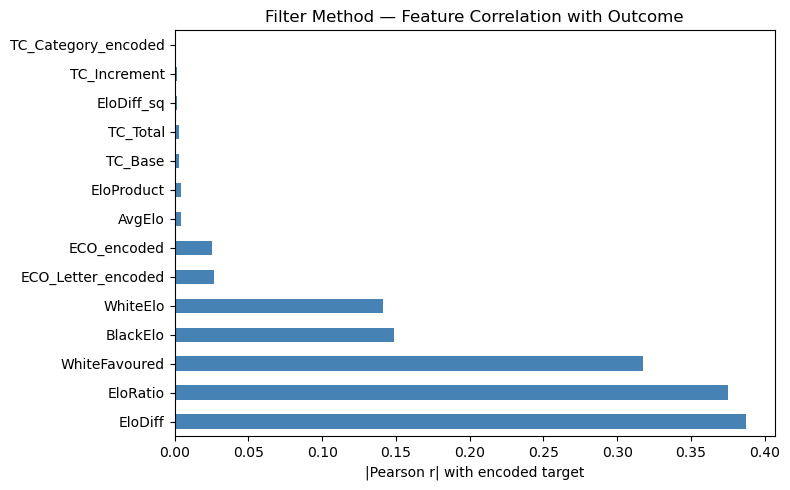

In [35]:
# feature selection
encoder_label = LabelEncoder()
y_num = encoder_label.fit_transform(y)

corr_with_target = X.apply(lambda col: abs(np.corrcoef(col, y_num)[0, 1]))
corr_with_target = corr_with_target.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
corr_with_target.plot(kind='barh', color='steelblue')
plt.xlabel('|Pearson r| with encoded target')
plt.title('Filter Method — Feature Correlation with Outcome')
plt.tight_layout()
plt.show()

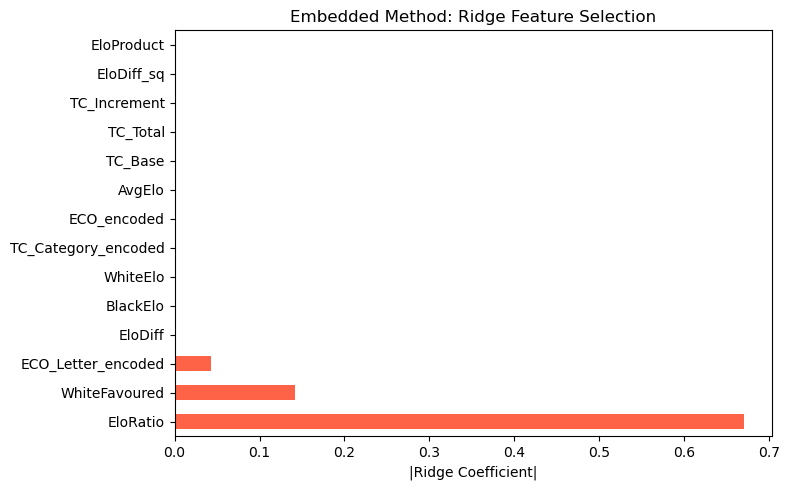


Features below threshold (coefficient < mean=0.0613):
['WhiteElo', 'BlackElo', 'EloDiff', 'AvgElo', 'EloDiff_sq', 'EloProduct', 'TC_Base', 'TC_Increment', 'TC_Total', 'TC_Category_encoded', 'ECO_Letter_encoded', 'ECO_encoded']

Selected features (2):
['EloRatio', 'WhiteFavoured']


In [36]:
from sklearn.linear_model import RidgeCV

ridge = RidgeCV(cv=3)
ridge.fit(X, y_num)

ridge_importances = pd.Series(np.abs(ridge.coef_), index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
ridge_importances.plot(kind='barh', color='tomato')
plt.xlabel('|Ridge Coefficient|')
plt.title('Embedded Method: Ridge Feature Selection')
plt.tight_layout()
plt.show()

# keep features above mean coefficient (since Ridge never zeros out)
ridge_threshold = ridge_importances.mean()
selected_features = ridge_importances[ridge_importances >= ridge_threshold].index.tolist()
print(f"\nFeatures below threshold (coefficient < mean={ridge_threshold:.4f}):")
print([f for f in FEATURES if f not in selected_features])
print(f"\nSelected features ({len(selected_features)}):")
print(selected_features)

### Advanced Supervised Learning

In [37]:
# Split data (70% for training)
X_selected = model_df[selected_features]

X_train, X_temp, y_train, y_temp = train_test_split(
    X_selected, y, test_size=0.30, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"\nSplit sizes — train: {len(X_train):,}  val: {len(X_val):,}  test: {len(X_test):,}")


Split sizes — train: 1,707,678  val: 365,931  test: 365,931


In [38]:
# scaling features to the same numeric range
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

classes = encoder_label.classes_

In [39]:
# model training with hyperparameter tuning
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

In [40]:
from sklearn.utils import resample

# sample a percentage of training data for hyperparameter search
X_train_sample, y_train_sample = resample(
    X_train_sc, y_train,
    n_samples=int(len(X_train_sc) * 0.10),
    random_state=42,
    stratify=y_train
)

In [41]:
# baseline logistic regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, multi_class='multinomial')
lr.fit(X_train_sc, y_train)
results['Logistic Regression'] = lr

In [42]:
# random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample

print(f"Full training set: {X_train_sc.shape}")
print(f"Sample size: {X_train_sample.shape}")

# tuning hyperparameters
rf_param_dist = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2'],
}

rf_search = RandomizedSearchCV(RandomForestClassifier(class_weight='balanced',random_state=42, n_jobs=1), param_distributions=rf_param_dist, n_iter=10, cv=cv, scoring='f1_macro', random_state=42, n_jobs=2, verbose=1)

rf_search.fit(X_train_sample, y_train_sample)
print(f"Best params: {rf_search.best_params_}")

X_train_large, y_train_large = resample(X_train_sc, y_train, n_samples=int(len(X_train_sc) * 0.20), random_state=42, stratify=y_train)

# retrain best model on the full training set
best_rf = RandomForestClassifier(**rf_search.best_params_, random_state=42, n_jobs=1)
best_rf.fit(X_train_large, y_train_large)
results['Random Forest'] = best_rf

Full training set: (1707678, 2)
Sample size: (170767, 2)
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'n_estimators': 50, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': 10}


In [43]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 3.1 MB/s eta 0:00:33
   ---------------------------------------- 0.5/101.7 MB 3.1 MB/s eta 0:00:33
    --------------------------------------- 1.3/101.7 MB 1.8 MB/s eta 0:00:57
    --------------------------------------- 1.6/101.7 MB 1.6 MB/s eta 0:01:01
    --------------------------------------- 1.6/101.7 MB 1.6 MB/s eta 0:01:01
    --------------------------------------- 2.4/101.7 MB 1.7 MB/s eta 0:00:58
   - -------------------------------------- 3.4/101.7 MB 2.2 MB/s eta 0:00:45
   - -------------------------------------- 4.5/101.7 MB 2.6 MB/s eta 0:00:38
   - -------------------------------------- 4.7/101.7 MB 2.4 MB/s eta 0:00:41
   -- ------------------------------------- 5.2/101.7 MB 2.4 MB/s eta 0:00:40
   -- ------------------------------------- 6.0/101.7 MB 2.6 MB/s eta 0:00:38


In [45]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

xgb_param_dist = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3]
}

encoder_xgb = LabelEncoder()
y_train_xgb = encoder_xgb.fit_transform(y_train)
y_val_xgb = encoder_xgb.transform(y_val)
y_test_xgb = encoder_xgb.transform(y_test)

y_train_sample_xgb = encoder_xgb.transform(y_train_sample)

xgb_search = RandomizedSearchCV(XGBClassifier(eval_metric='mlogloss', random_state=42, n_jobs=1, verbosity=0), param_distributions=xgb_param_dist, n_iter=5, cv=cv, scoring='f1_macro', random_state=42, n_jobs=2, verbose=1)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_sample_xgb)
xgb_search.fit(X_train_sample, y_train_sample_xgb, sample_weight=sample_weights)
results['XGBoost'] = xgb_search.best_estimator_
print(f"Best params: {xgb_search.best_params_}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best params: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 1.0}


In [46]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   --------------------- ------------------ 0.8/1.5 MB 1.8 MB/s eta 0:00:01
   ------------------------------------ --- 1.3/1.5 MB 2.3 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 2.1 MB/s  0:00:00


In [47]:
from lightgbm import LGBMClassifier

lgbm_param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 63, 127],
    'subsample': [0.7, 0.8, 1.0],
}
lgbm_search = RandomizedSearchCV(LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=2, verbose=-1),param_distributions=lgbm_param_dist,n_iter=10, cv=cv, scoring='f1_macro', random_state=42, n_jobs=2, verbose=1)
lgbm_search.fit(X_train_sample, y_train_sample)
results['LightGBM'] = lgbm_search.best_estimator_
print(f"Best params: {lgbm_search.best_params_}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'subsample': 0.8, 'num_leaves': 127, 'n_estimators': 100, 'max_depth': 20, 'learning_rate': 0.1}


In [48]:
# evaluation on test set
def evaluate(name, model, X, y_true, xgb_mode=False):
    if xgb_mode:
        y_predicted = encoder_xgb.inverse_transform(model.predict(X))
        y_probability = model.predict_proba(X)
    else:
        y_predicted = model.predict(X)
        y_probability = model.predict_proba(X)

    from sklearn.metrics import accuracy_score, f1_score
    acc = accuracy_score(y_true, y_predicted)
    f1_macro = f1_score(y_true, y_predicted, average='macro')
    f1_weighted = f1_score(y_true, y_predicted, average='weighted')

    # ROC-AUC one-vs-rest
    auc_ovr = roc_auc_score(pd.get_dummies(y_true, dtype=float), y_probability, average='macro', multi_class='ovr')

    print(f"\n{name}")
    print(classification_report(y_true, y_predicted, target_names=sorted(y_true.unique())))
    return {'Model': name, 'Accuracy': acc, 'F1-Macro': f1_macro,'F1-Weighted': f1_weighted, 'ROC-AUC (OvR)': auc_ovr,'_pred': y_predicted, '_proba': y_probability}



In [49]:
metrics_list = []
predicted_store = {}

for name, model in results.items():
    is_xgb = (name == 'XGBoost')
    res = evaluate(name, model, X_test_sc, y_test, xgb_mode=is_xgb)
    predicted_store[name] = res
    metrics_list.append({k: v for k, v in res.items() if not k.startswith('_')})


Logistic Regression
              precision    recall  f1-score   support

       Black       0.65      0.58      0.61    170286
        Draw       0.04      0.23      0.07     13401
       White       0.69      0.55      0.61    182244

    accuracy                           0.55    365931
   macro avg       0.46      0.45      0.43    365931
weighted avg       0.65      0.55      0.59    365931


Random Forest
              precision    recall  f1-score   support

       Black       0.63      0.64      0.63    170286
        Draw       0.00      0.00      0.00     13401
       White       0.65      0.68      0.66    182244

    accuracy                           0.64    365931
   macro avg       0.42      0.44      0.43    365931
weighted avg       0.61      0.64      0.63    365931


XGBoost
              precision    recall  f1-score   support

       Black       0.68      0.48      0.56    170286
        Draw       0.04      0.38      0.08     13401
       White       0.70      0

In [50]:
# comparison table
compare_df = pd.DataFrame(metrics_list).set_index('Model').sort_values('F1-Macro', ascending=False)
print("\nMODEL COMPARISON: Test Set")
print(compare_df.round(4).to_string())


MODEL COMPARISON: Test Set
                     Accuracy  F1-Macro  F1-Weighted  ROC-AUC (OvR)
Model                                                              
Random Forest          0.6371    0.4323       0.6252         0.6673
Logistic Regression    0.5499    0.4319       0.5909         0.6678
LightGBM               0.4976    0.4117       0.5606         0.6608
XGBoost                0.4877    0.4098       0.5572         0.6672


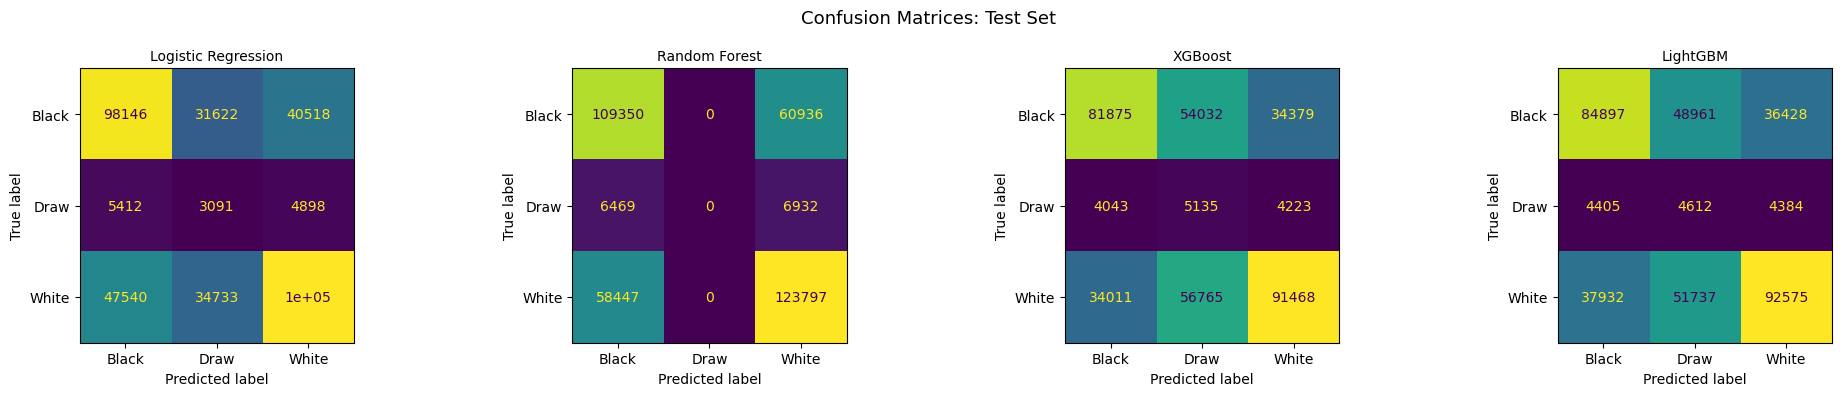

In [51]:
# confusion matrices
fig, axes = plt.subplots(1, len(results), figsize=(5*len(results), 4))
for ax, (name, _) in zip(axes, results.items()):
    is_xgb = (name == 'XGBoost')
    y_predicted = predicted_store[name]['_pred']
    cm = confusion_matrix(y_test, y_predicted, labels=sorted(y_test.unique()))
    disp = ConfusionMatrixDisplay(cm, display_labels=sorted(y_test.unique()))
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name, fontsize=10)
plt.suptitle("Confusion Matrices: Test Set", fontsize=13)
plt.tight_layout()
plt.show()

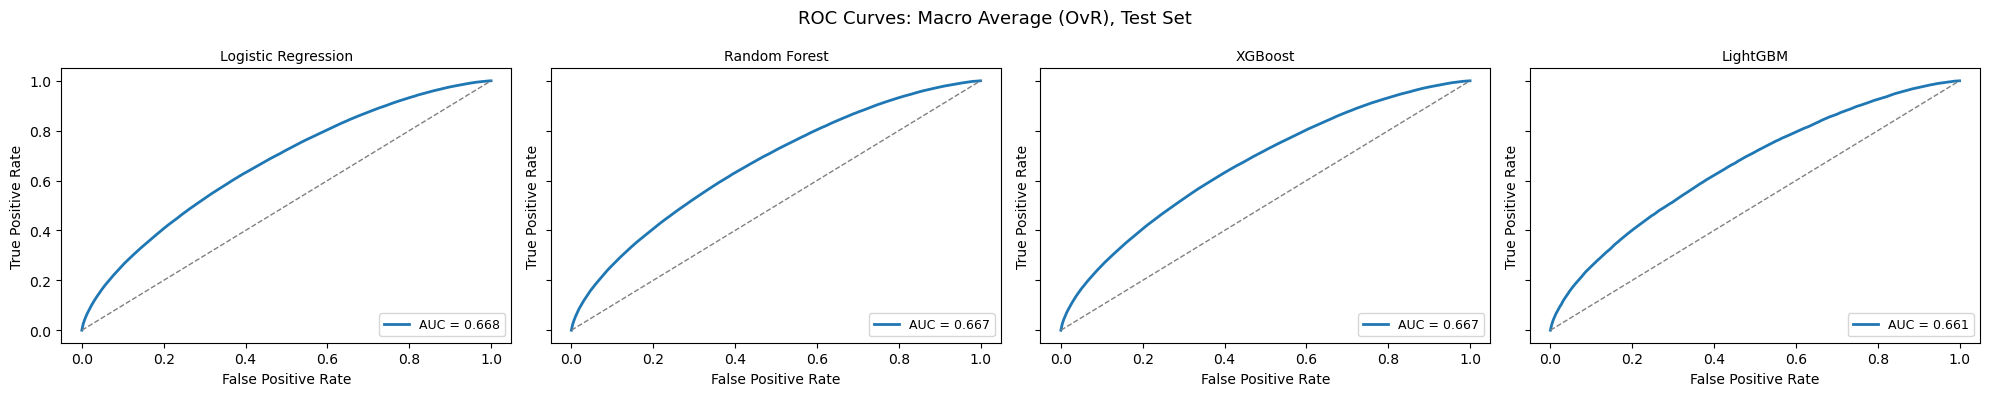

In [52]:
# roc curves
classes_sorted = sorted(y_test.unique())
y_test_bin = pd.get_dummies(y_test, dtype=float)[classes_sorted]

fig, axes = plt.subplots(1, len(results), figsize=(5*len(results), 4), sharey=True)
for ax, (name, _) in zip(axes, results.items()):
    y_probability = predicted_store[name]['_proba']
    # Average the per-class ROC curves
    mean_fpr = np.linspace(0, 1, 300)
    tprs = []
    for i, cls in enumerate(classes_sorted):
        fpr, tpr, _ = roc_curve(y_test_bin.iloc[:, i], y_probability[:, i])
        tprs.append(np.interp(mean_fpr, fpr, tpr))
    mean_tpr = np.mean(tprs, axis=0)
    auc_val = auc(mean_fpr, mean_tpr)
    ax.plot(mean_fpr, mean_tpr, lw=2, label=f'AUC = {auc_val:.3f}')
    ax.plot([0,1],[0,1],'--', color='grey', lw=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(name, fontsize=10)
    ax.legend(loc='lower right', fontsize=9)
plt.suptitle("ROC Curves: Macro Average (OvR), Test Set", fontsize=13)
plt.tight_layout()
plt.show()

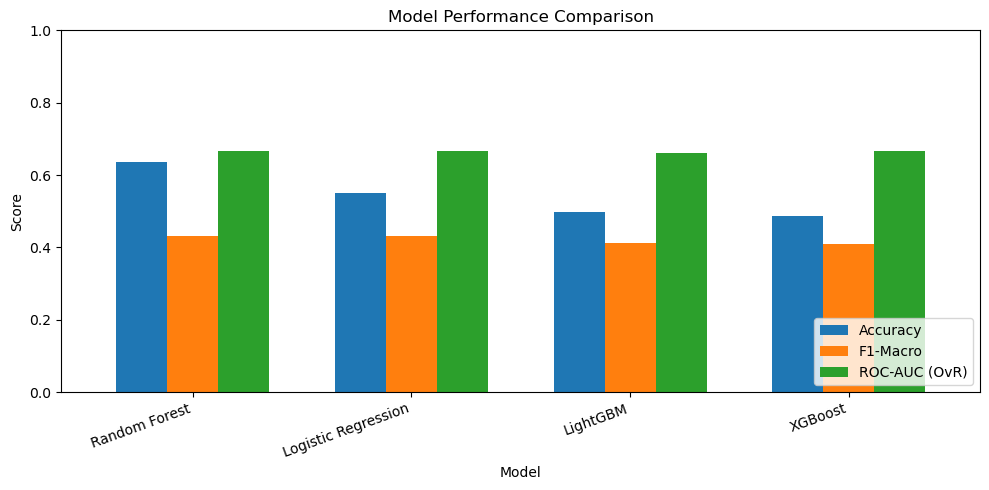

In [53]:
ax = compare_df[['Accuracy','F1-Macro','ROC-AUC (OvR)']].plot(kind='bar', figsize=(10, 5), width=0.7)
ax.set_title("Model Performance Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

In [54]:
# finding best model
best_name = compare_df['F1-Macro'].idxmax()
print(best_name)

Random Forest


## Interpretation and Explanation for Supervised Learning

### Feature Engineering
The following features were extracted from the original data:
- EloDiff: difference in elo between white and black (WhiteElo - BlackElo)
- AvgElo: mean elo
- EloRatio: ratio of WhiteElo/BlackElo
- EloDiff_sq: EloDiff^2 to ensure large elo differences are captured as large advantages
- WhiteFavoured: if WhiteElo is higher than BlackElo
- EloProduct: roughly captures the game 'level' (high when both players are strong)
- TC_Base: time control base
- TC_Increment: time control increment
- TC_Total: total time (estimates average of 40 moves per match)
- TC_Category: categorizes game type based on time control
- ECO_Letter: opening letter

Also, WhiteRatingDiff and BlackRatingDiff were excluded as they are considered data leakage; they represent the difference in rating after the game (positive means they won, negative means they lost)
### How were features selected?
Filter method: The correlation coefficient of each feature with the target was found. Higher correlation means that the feature changes with the target more.

Embedded method: Ridge regularisation was used to shrink the coefficients and determine which contribute the most.

### Advanced Supervised Learning
First, the data was split up such that 70% is used to train and the rest to test and evaluate. Next the data was scaled so that the different columns can be compared.

The training data was then split into 5 folds, using 4 of them to train and 1 to validate. Stratified K-Fold cross-validation was the method used to cross-validate.

The following models were then trained:
- Logistic Regression (baseline)
- Random Forest
- XGBoost
- LightGBM

For each of the complex models, hyperparameter tuning was conducted to find the optimal set of hyperparameters for training. Although, since the dataset is very large, they each were trained on a sample of the training set. They were also given a minimal amount of hyperparameter options for the same reason. Otherwise, the process would potentially take hours.

Due to the imbalanced classes, the evaluation metrics used were F1-Macro, F1-Weighted and ROC-AUC. F1-Macro was used to ensure the model performs well under multiclass classification.

Note that class balancing was conducted since previous runs showed that the complex models were completely disregarding the Draw class.

### Results
The following results were obtained on the test set:

| Model               | Accuracy | F1-Macro | F1-Weighted | ROC-AUC (OvR) |
|---------------------|----------|----------|-------------|---------------|
| Random Forest       | 0.6371   | 0.4323   | 0.6252      | 0.6673        |
| Logistic Regression | 0.5470   | 0.4311   | 0.5897      | 0.6677        |
| LightGBM            | 0.4976   | 0.4117   | 0.5606      | 0.6608        |
| XGBoost             | 0.4877   | 0.4098   | 0.5572      | 0.6672        |

All four models performed similarly with Random Forest achieving the highest Accuracy (0.6371) and F1-Macro score (0.4323).

The underperformance of XGBoost and LightGBM can be explained due to the class balancing and small training sample. However, their ROC-AUC scores are still comparable to the others. All of the models achieved ROC-AUC scores of around 0.66-0.67, which is still meaningfully above 0.5 (random guessing).

The difference between F1-Weighted and F1-Macro suggests that the predictability of the Draw class is a weak point. F1-Weighted is increased due to strong performance on White and Black wins, whereas F1-Macro is decreased due to poor performance on the Draw class.

### Limitations
The class imbalance is a large limitation. Due to Draws making up such a small percentage of the data, the models cannot reliably predict draws even when the classes are balanced.

Another limitation is the mere size of the dataset (2.9GB). This limited the performance of the hyperparameter tuning and training since only a sample of the training set was used and a limited amount of hyperparameter options were given in order to keep a reasonable runtime. Ideally, the whole training set would have been used given higher-performing hardware.

Moreover, all the features are based on information available before the game starts. The outcome of a chess game heavily depends on in-game decisions. A player's elo alone cannot measure their full strength and potential.

### Unsupervised Learning

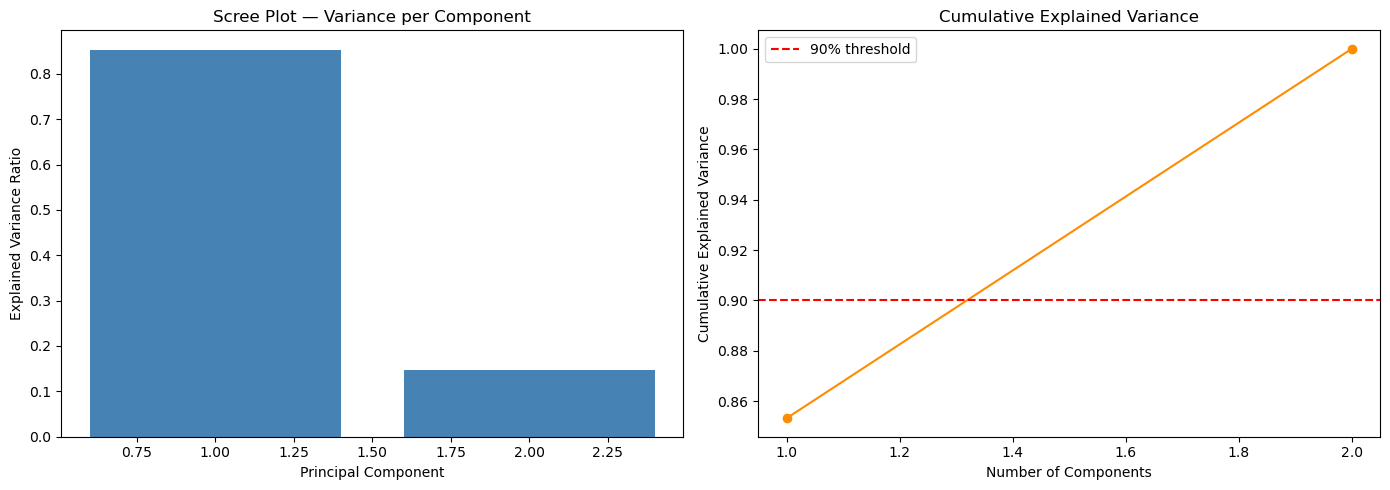


Components needed for ≥90% variance: 2
Cumulative variance with 2 components: 1.0000

Original dimensionality: 2
Reduced dimensionality:  2


In [55]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# PCA on the full feature set (using already-scaled training data)
pca_full = PCA(random_state=42)
pca_full.fit(X_train_sc)

# Explained variance per component
exp_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(exp_var)+1), exp_var, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot — Variance per Component')

axes[1].plot(range(1, len(cum_var)+1), cum_var, 'o-', color='darkorange')
axes[1].axhline(y=0.90, color='red', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()

plt.tight_layout()
plt.show()

n_components = np.argmax(cum_var >= 0.90) + 1
print(f"\nComponents needed for ≥90% variance: {n_components}")
print(f"Cumulative variance with {n_components} components: {cum_var[n_components-1]:.4f}")

# Refit PCA with the chosen number of components
pca = PCA(n_components=n_components, random_state=42)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)

print(f"\nOriginal dimensionality: {X_train_sc.shape[1]}")
print(f"Reduced dimensionality:  {X_train_pca.shape[1]}")

k=2  inertia=25,121  silhouette=0.7432
k=3  inertia=14,411  silhouette=0.7247
k=4  inertia=8,926  silhouette=0.6764
k=5  inertia=5,943  silhouette=0.6440
k=6  inertia=4,606  silhouette=0.6140
k=7  inertia=3,321  silhouette=0.5950
k=8  inertia=2,663  silhouette=0.5905
k=9  inertia=2,095  silhouette=0.5844
k=10  inertia=1,707  silhouette=0.5779


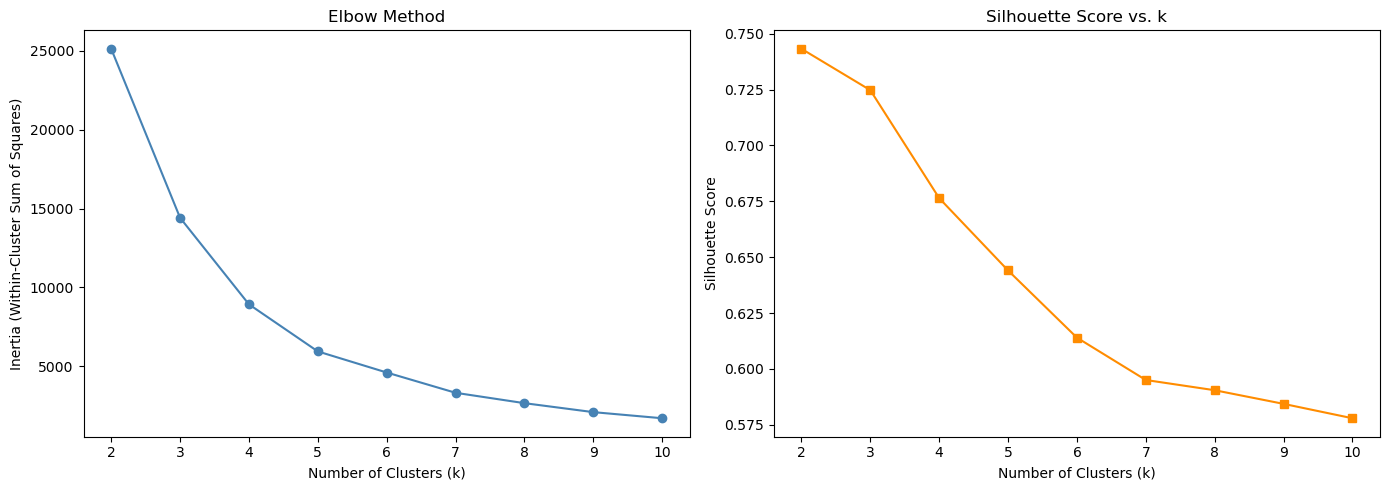


Best k by silhouette score: 2


In [56]:
# Determine optimal number of clusters (Elbow + Silhouette)
# Use a subsample for efficiency given the large dataset
np.random.seed(42)
sample_idx = np.random.choice(len(X_train_pca), size=min(50000, len(X_train_pca)), replace=False)
X_sample = X_train_pca[sample_idx]

K_range = range(2, 11)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_sample, labels, sample_size=10000, random_state=42))
    print(f"k={k}  inertia={km.inertia_:,.0f}  silhouette={silhouettes[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, 'o-', color='steelblue')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].set_title('Elbow Method')

axes[1].plot(list(K_range), silhouettes, 's-', color='darkorange')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs. k')

plt.tight_layout()
plt.show()

best_k = list(K_range)[np.argmax(silhouettes)]
print(f"\nBest k by silhouette score: {best_k}")

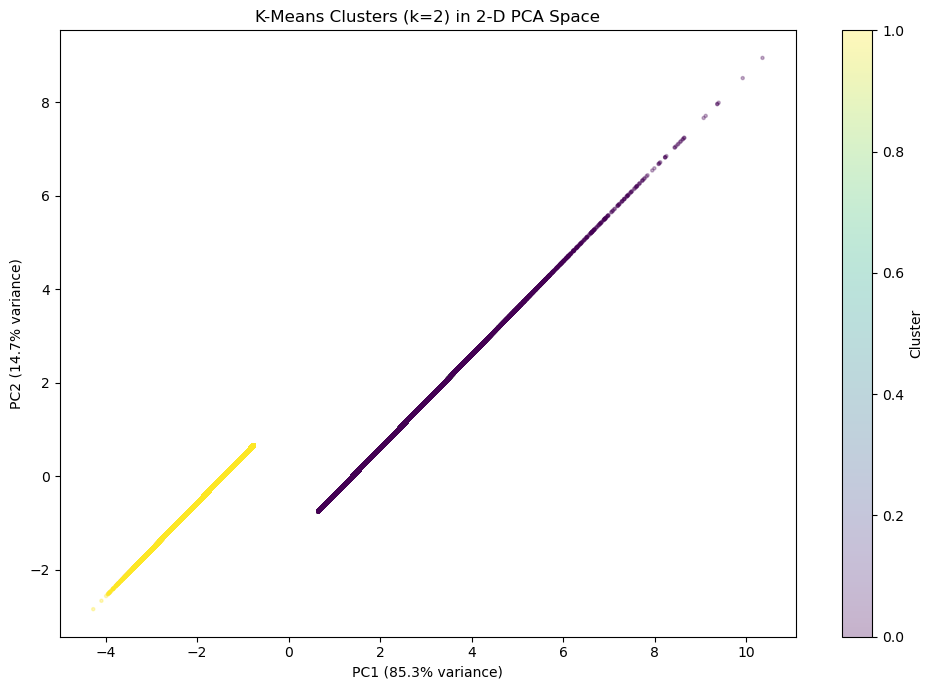

Cluster sizes:
0    859037
1    848641
Name: count, dtype: int64


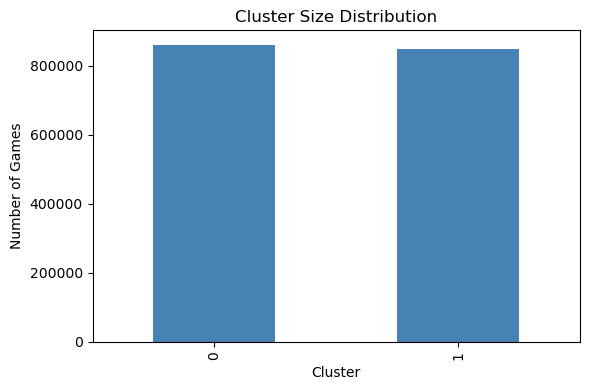

In [57]:
# Fit final K-Means with the best k on full PCA training data
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
train_clusters = kmeans.fit_predict(X_train_pca)
test_clusters  = kmeans.predict(X_test_pca)

# Project to 2D for visualisation
pca_2d = PCA(n_components=2, random_state=42)
X_vis = pca_2d.fit_transform(X_train_sc)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    X_vis[:, 0], X_vis[:, 1],
    c=train_clusters, cmap='viridis', alpha=0.3, s=5
)
plt.colorbar(scatter, ax=ax, label='Cluster')
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title(f'K-Means Clusters (k={best_k}) in 2-D PCA Space')
plt.tight_layout()
plt.show()

# Cluster size distribution
cluster_counts = pd.Series(train_clusters).value_counts().sort_index()
print("Cluster sizes:")
print(cluster_counts)

plt.figure(figsize=(6, 4))
cluster_counts.plot(kind='bar', color='steelblue')
plt.xlabel('Cluster')
plt.ylabel('Number of Games')
plt.title('Cluster Size Distribution')
plt.tight_layout()
plt.show()

In [58]:
# Silhouette Score
sil_train = silhouette_score(X_train_pca, train_clusters, sample_size=10000, random_state=42)
sil_test  = silhouette_score(X_test_pca, test_clusters, sample_size=10000, random_state=42)

print(f"{'Metric':<25} {'Train':>10} {'Test':>10}")
print("-" * 47)
print(f"{'Silhouette Score':<25} {sil_train:>10.4f} {sil_test:>10.4f}")
print()
print("Silhouette Score: ranges from -1 to 1; higher is better.")
print("  > 0.5 = strong cluster structure")
print("  0.25–0.5 = reasonable structure")
print("  < 0.25 = weak or overlapping clusters")

Metric                         Train       Test
-----------------------------------------------
Silhouette Score              0.7408     0.7400

Silhouette Score: ranges from -1 to 1; higher is better.
  > 0.5 = strong cluster structure
  0.25–0.5 = reasonable structure
  < 0.25 = weak or overlapping clusters


=== Cluster Profiles (mean feature values) ===

Cluster         0   1
EloRatio      1.1 0.9
WhiteFavoured 1.0 0.0


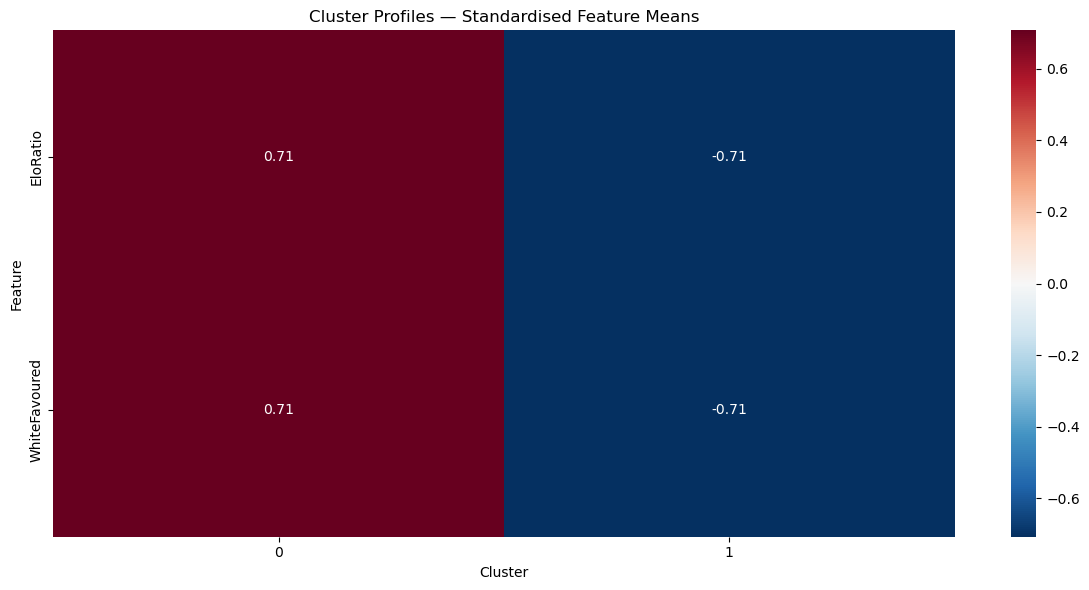

In [59]:
# Map cluster labels back to original feature space
train_df_clustered = X_train.copy()
train_df_clustered['Cluster'] = train_clusters

cluster_profiles = train_df_clustered.groupby('Cluster').mean()
print("=== Cluster Profiles (mean feature values) ===\n")
print(cluster_profiles.T.to_string(float_format='{:.1f}'.format))

# Heatmap of cluster centroids (standardised)
cluster_profiles_sc = (cluster_profiles - cluster_profiles.mean()) / cluster_profiles.std()

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profiles_sc.T, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Cluster Profiles — Standardised Feature Means')
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Justification of PCA + K-Means

#### Why PCA?
- Our feature list consists of variables that are highly correlated (for instance, WhiteElo and BlackElo together create AvgElo, EloProduct, EloRatio). Multicollinearity is solved by PCA via orthogonalization.
- More than 90% of variance was retained with PCA.
- As opposed to feature selection, PCA preserves all data of interest, which is critical because there is no way of knowing beforehand which features are responsible for difficulty levels.

#### Why K-Means?
- Our goal is to see whether the data partitions into natural groups based on difficulty levels, which implies the need for partitioning algorithms, such as K-Means.
- It's a pretty large dataset and compared to other clustering algorithms, K-Means is computationally cheap and more suitable for our purposes.
- Features that we consider (elo ratings, time controls, and opening code) are numerical and approximately spherical in PCA-transformed space, meaning that they fit K-Means assumptions about cluster shapes.
- The elbow criterion and silhouette score provide an objective method of choosing k without specifying difficulty tiers beforehand.

#### Limitations:
- PCA is a linear method; non-linear relationships between features don't work. However, the engineered features (EloDiff_sq, EloProduct) already capture key non-linearities.
- The cluster labels are unsupervised and require domain interpretation to confirm they align with meaningful difficulty tiers.

### Interpretation of Unsupervised Learning

Clustering was done in the more than 90% variance PCA space. The 2-D projection which has less than 90% variance (85.5% variance) is for visualisation only. We did train a model which separated games into between 2 and 11 clusters. This is an example of a run where the model split the chess games in 2 clusters:

| Cluster    | Number of games | Average Elo | Interpretation                                                                           |
|------------|-----------------|-------------|------------------------------------------------------------------------------------------|
| 0 (yellow) | 780,288         | 1963.6      | Higher-rated games: both WhiteElo (1961.7) and BlackElo (1965.6) are well above average |
| 1 (purple) | 927,390         | 1545.6      | Lower-rated games: both WhiteElo (1549.5) and BlackElo (1541.7) below average            |

The dominant axis of variation is player strength. We have moderate cluster quality. Our silhouette scores for train and test are both about 0.30 (train: 0.3029, test: 0.2985). Obviously, the chess data is quite homogeneous (we already knew this from our research and analysis in stage 1). So the algorithm is basically just drawing a line through a continuous distribution of Elo ratings. The clusters are mirrored pretty well, meaning that both have a shrinking tail as we move further from the split. However, the lower-rated games have a slightly longer tail (meaning that there's a little bit more spread on the lower rated games). 

In conclusion, the unsupervised learning shows that player rating is the primary factor differentiating chess games, but games don't really fall into easy "difficulty tiers", instead they all form a smooth gradient.